# A-S Baseline — 30-Day Evaluation (Falces Marin Tables 2–5)

Runs the calibrated A-S agent on every day of DOGEUSDT data.  
Produces one table per metric with per-day rows and summary statistics.

In [2]:
import sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = pathlib.Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from procs.stochastic_processes.midprice_models import MarketReplayMidpriceModel
from procs.gym.helpers.fast_rollout import fast_simulate
from procs.gym.data_loader import load_multi_day

%matplotlib inline

## 1. Load All Days

In [3]:
DATA_DIR = r"C:\Users\john-\Documents\Thesis_AI4T\datasets"
daily_S, daily_dt, dates = load_multi_day(DATA_DIR, pair="DOGEUSDT")

  2025-01-01:  713,815 snapshots, σ=0.000021
  2025-01-02:  766,464 snapshots, σ=0.000035
  2025-01-03:  776,383 snapshots, σ=0.000047
  2025-01-04:  778,293 snapshots, σ=0.000045
  2025-01-05:  723,494 snapshots, σ=0.000031
  2025-01-06:  766,311 snapshots, σ=0.000035
  2025-01-07:  787,093 snapshots, σ=0.000062
  2025-01-08:  821,589 snapshots, σ=0.000052
  2025-01-09:  809,421 snapshots, σ=0.000046
  2025-01-10:  789,320 snapshots, σ=0.000045
  2025-01-11:  724,826 snapshots, σ=0.000023
  2025-01-12:  719,550 snapshots, σ=0.000022
  2025-01-13:  819,981 snapshots, σ=0.000046
  2025-01-14:  775,454 snapshots, σ=0.000038
  2025-01-15:  782,299 snapshots, σ=0.000047
  2025-01-16:  788,946 snapshots, σ=0.000048
  2025-01-17:  801,259 snapshots, σ=0.000061
  2025-01-18:  829,125 snapshots, σ=0.000074
  2025-01-19:  842,892 snapshots, σ=0.000096
  2025-01-20:  857,508 snapshots, σ=0.000115
  2025-01-21:  848,107 snapshots, σ=0.000112
  2025-01-22:  812,180 snapshots, σ=0.000044
  2025-01-

## 2. Parameters

In [4]:
kappa     = 35_000
A         = 0.8
tick_size = 0.00001
Q_MAX     = 50
gamma     = 0.01   # replace with Optuna-tuned value
N_traj    = 50     # trajectories per day for averaging
seed      = 42

## 3. Run A-S on Every Day

In [5]:
results = []

for i, (S, dt, date) in enumerate(zip(daily_S, daily_dt, dates)):
    T = float(dt.sum())
    sigma = MarketReplayMidpriceModel(S, dt).volatility

    stats = fast_simulate(
        midprices=S, dt_array=dt,
        gamma=gamma, sigma=sigma, kappa=kappa, A=A,
        terminal_time=T, tick_size=tick_size, Q_MAX=Q_MAX,
        num_trajectories=N_traj, seed=seed,
        use_linear_approximation=False,
    )

    results.append({
        "Day": date,
        "Sharpe": stats["sharpe"].mean(),
        "Sortino": stats["sortino"].mean(),
        "Max DD": stats["max_drawdown"].mean(),
        "P&L-to-MAP": stats["pnl_to_map"].mean(),
        "Final PnL": stats["total_pnl"].mean(),
        "Mean |q|": stats["mean_abs_q"].mean(),
        "sigma": sigma,
    })

    print(f"  {date}  Sharpe={stats['sharpe'].mean():+.4f}  "
          f"MaxDD={stats['max_drawdown'].mean():.4f}  "
          f"PnL={stats['total_pnl'].mean():+.4f}")

df = pd.DataFrame(results).set_index("Day")
print(f"\nDone: {len(df)} days.")

  2025-01-01  Sharpe=+0.0136  MaxDD=0.1155  PnL=+1.3160
  2025-01-02  Sharpe=+0.0191  MaxDD=0.0706  PnL=+1.3347
  2025-01-03  Sharpe=+0.0138  MaxDD=0.1135  PnL=+1.3559
  2025-01-04  Sharpe=+0.0144  MaxDD=0.1436  PnL=+1.3422
  2025-01-05  Sharpe=+0.0171  MaxDD=0.0845  PnL=+1.3494
  2025-01-06  Sharpe=+0.0172  MaxDD=0.0804  PnL=+1.3517
  2025-01-07  Sharpe=+0.0163  MaxDD=0.0782  PnL=+1.3392
  2025-01-08  Sharpe=+0.0166  MaxDD=0.0784  PnL=+1.3358
  2025-01-09  Sharpe=+0.0155  MaxDD=0.0841  PnL=+1.3322
  2025-01-10  Sharpe=+0.0184  MaxDD=0.0647  PnL=+1.3387
  2025-01-11  Sharpe=+0.0127  MaxDD=0.1886  PnL=+1.3330
  2025-01-12  Sharpe=+0.0142  MaxDD=0.1117  PnL=+1.3267
  2025-01-13  Sharpe=+0.0164  MaxDD=0.0680  PnL=+1.3482
  2025-01-14  Sharpe=+0.0160  MaxDD=0.0825  PnL=+1.3841
  2025-01-15  Sharpe=+0.0135  MaxDD=0.1452  PnL=+1.3201
  2025-01-16  Sharpe=+0.0164  MaxDD=0.0963  PnL=+1.3411
  2025-01-17  Sharpe=+0.0179  MaxDD=0.0651  PnL=+1.3497
  2025-01-18  Sharpe=+0.0176  MaxDD=0.0759  PnL=

## 4. Full Summary Table

In [6]:
summary = pd.DataFrame({
    col: [df[col].mean(), df[col].std(), df[col].median()]
    for col in df.columns
}, index=["Mean", "Std", "Median"])

full = pd.concat([df, summary])
print(full.to_string(float_format="%.6f"))

             Sharpe  Sortino   Max DD  P&L-to-MAP  Final PnL  Mean |q|    sigma
2025-01-01 0.013623 0.004780 0.115474    0.093948   1.316019 14.088083 0.000021
2025-01-02 0.019073 0.007624 0.070565    0.184508   1.334749  7.308736 0.000035
2025-01-03 0.013824 0.005617 0.113526    0.258368   1.355886  5.284453 0.000047
2025-01-04 0.014390 0.005410 0.143608    0.252382   1.342167  5.397245 0.000045
2025-01-05 0.017113 0.006000 0.084465    0.159148   1.349402  8.551723 0.000031
2025-01-06 0.017163 0.006617 0.080437    0.185727   1.351725  7.315530 0.000035
2025-01-07 0.016297 0.007165 0.078246    0.357870   1.339155  3.764780 0.000062
2025-01-08 0.016604 0.008036 0.078424    0.303543   1.335836  4.435598 0.000052
2025-01-09 0.015451 0.007608 0.084080    0.256433   1.332154  5.254606 0.000046
2025-01-10 0.018447 0.008608 0.064723    0.255703   1.338712  5.269005 0.000045
2025-01-11 0.012670 0.004468 0.188553    0.110569   1.332982 12.164061 0.000023
2025-01-12 0.014208 0.004926 0.111710   

## 5. Per-Metric Tables (Falces Marin style)

In [7]:
for metric in ["Sharpe", "Sortino", "Max DD", "P&L-to-MAP", "Final PnL"]:
    col = df[[metric]]
    s = pd.DataFrame({
        metric: [col[metric].mean(), col[metric].std(), col[metric].median()]
    }, index=["Mean", "Std", "Median"])
    table = pd.concat([col, s])
    print(f"\n{'='*50}")
    print(f"  {metric}")
    print(f"{'='*50}")
    print(table.to_string(float_format="%.6f"))


  Sharpe
             Sharpe
2025-01-01 0.013623
2025-01-02 0.019073
2025-01-03 0.013824
2025-01-04 0.014390
2025-01-05 0.017113
2025-01-06 0.017163
2025-01-07 0.016297
2025-01-08 0.016604
2025-01-09 0.015451
2025-01-10 0.018447
2025-01-11 0.012670
2025-01-12 0.014208
2025-01-13 0.016369
2025-01-14 0.015952
2025-01-15 0.013520
2025-01-16 0.016368
2025-01-17 0.017881
2025-01-18 0.017644
2025-01-19 0.008854
2025-01-20 0.017420
2025-01-21 0.020235
2025-01-22 0.010068
2025-01-23 0.014095
2025-01-24 0.015061
2025-01-25 0.015325
2025-01-26 0.013351
2025-01-27 0.019247
2025-01-28 0.012542
2025-01-29 0.012225
Mean       0.015345
Std        0.002681
Median     0.015451

  Sortino
            Sortino
2025-01-01 0.004780
2025-01-02 0.007624
2025-01-03 0.005617
2025-01-04 0.005410
2025-01-05 0.006000
2025-01-06 0.006617
2025-01-07 0.007165
2025-01-08 0.008036
2025-01-09 0.007608
2025-01-10 0.008608
2025-01-11 0.004468
2025-01-12 0.004926
2025-01-13 0.008220
2025-01-14 0.006921
2025-01-15 0.005656

## 6. Bar Charts

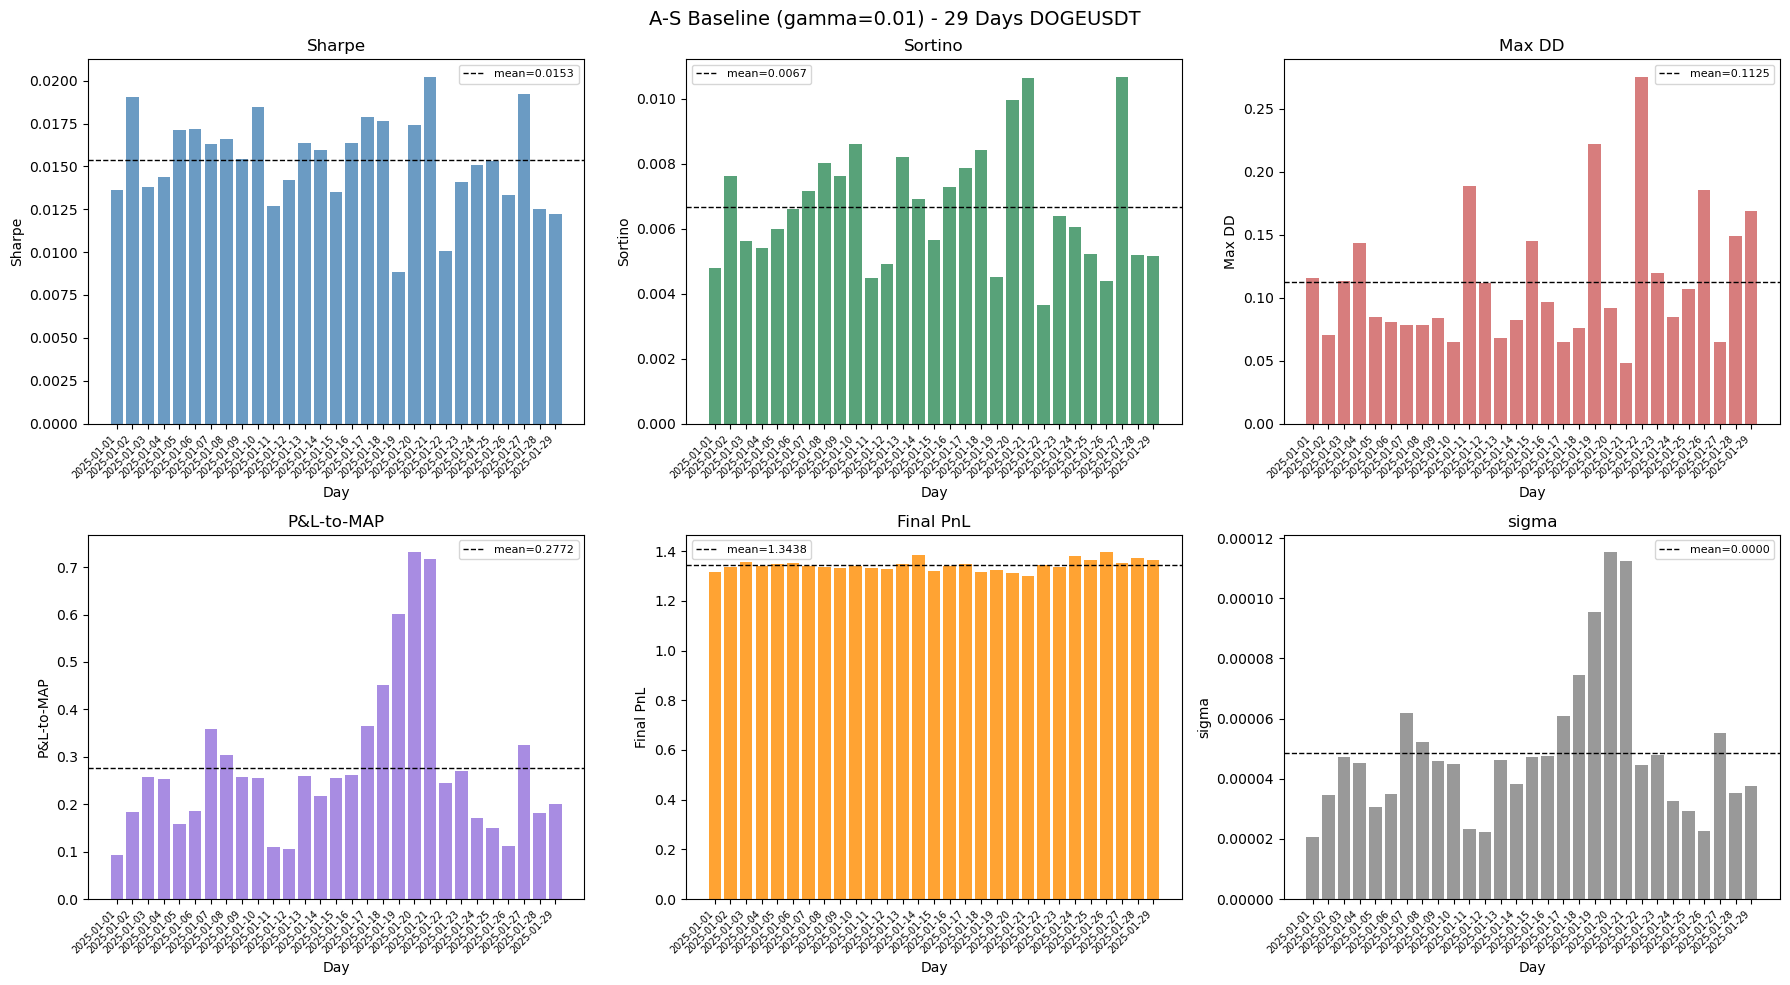

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics = ["Sharpe", "Sortino", "Max DD", "P&L-to-MAP", "Final PnL", "sigma"]
colors = ["steelblue", "seagreen", "indianred", "mediumpurple", "darkorange", "grey"]

for ax, metric, color in zip(axes.flat, metrics, colors):
    ax.bar(range(len(df)), df[metric], color=color, alpha=0.8)
    ax.axhline(y=df[metric].mean(), color="k", ls="--", lw=1,
               label=f"mean={df[metric].mean():.4f}")
    ax.set_title(metric)
    ax.set_xlabel("Day")
    ax.set_ylabel(metric)
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(df.index, rotation=45, ha="right", fontsize=7)
    ax.legend(fontsize=8)

plt.suptitle(f"A-S Baseline (gamma={gamma}) - {len(df)} Days DOGEUSDT", fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
df.to_csv("C:/Users/john-/Documents/Thesis_AI4T/modelsas_baseline_30day_results.csv")
print("Saved to models/as_baseline_30day_results.csv")

Saved to models/as_baseline_30day_results.csv
